# 准备数据

In [1]:
import sys
sys.path.append('/home/hyd/research/vnpy_hub')
sys.path.append('/home/hyd/research/vnpy_hub/vnpy')

In [2]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

import json

In [4]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/all_stocks")

In [5]:
# 设置任务参数
name = "300_mlp"
index_symbol: str = "000300.SSE"
start: str = "2017-01-01"
end: str = "2025-08-01"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [6]:
# 读取参数
from pathlib import Path

# 优先从命令行第一个参数读取JSON路径，否则默认同目录 config.json
_cfg_path = Path(sys.argv[1]) if len(sys.argv) > 1 else Path(__file__).with_name("config.json")
if _cfg_path.exists():
    with open(_cfg_path, encoding="utf-8") as _f:
        params = json.load(_f)
else:
    params = {}

name = params.get("name", "300_mlp")
index_symbol: str = params.get("index_symbol", "000300.SSE")
start: str = params.get("start", "2017-01-01")
end: str = params.get("end", "2025-08-01")
_interval_str = params.get("interval", "1d")
interval: Interval = Interval.DAILY if _interval_str == "1d" else (
    Interval.MINUTE if _interval_str in {"1m", "10m", "30m"} else Interval.HOUR
)
extended_days: int = int(params.get("extended_days", 100))

dataset_format: str = params.get("dataset_format", "parquet")


In [7]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [8]:
# 加载模块
from datetime import datetime
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_robust_zscore_norm,
    process_fill_na,
    process_cs_rank_norm,
    to_datetime
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [9]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [10]:
# 设置数据时间段（支持JSON）
train_period: tuple[str, str] = tuple(params.get("train_period", ["2017-01-01", "2021-12-31"]))  # type: ignore[assignment]
valid_period: tuple[str, str] = tuple(params.get("valid_period", ["2022-01-01", "2022-12-31"]))  # type: ignore[assignment]
test_period: tuple[str, str] = tuple(params.get("test_period", ["2023-01-01", "2025-08-01"]))    # type: ignore[assignment]


In [11]:
# 
# 简单断言：三段时间不重叠
_tp0, _tp1 = to_datetime(train_period[0]), to_datetime(train_period[1])
_vp0, _vp1 = to_datetime(valid_period[0]), to_datetime(valid_period[1])
_sp0, _sp1 = to_datetime(test_period[0]), to_datetime(test_period[1])
assert _tp1 < _vp0 and _vp1 < _sp0, "train/valid/test 时间段存在重叠，请检查配置"


In [12]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period=train_period,
    valid_period=valid_period,
    test_period=test_period,
)

In [13]:
# 运行参数写入数据集，随缓存一并保存
setattr(dataset, "params", params)

In [14]:
# 添加数据预处理器
fit_start_time: datetime = to_datetime(train_period[0])
fit_end_time: datetime = to_datetime(train_period[1])

dataset.add_processor("infer", partial(process_robust_zscore_norm, fit_start_time=fit_start_time, fit_end_time=fit_end_time))
dataset.add_processor("infer", partial(process_fill_na, fill_value=0, fill_label=False))

dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_rank_norm, names=["label"]))

In [15]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [16]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=50)

2025-10-23 13:41:45 开始计算表达式因子特征


  1%|          | 1/159 [00:01<03:58,  1.51s/it]

Feature calculation kmid took: 0.05853843688964844 seconds | (close - open) / open


  1%|▏         | 2/159 [00:01<02:21,  1.11it/s]

Feature calculation klen took: 0.038277626037597656 seconds | (high - low) / open
Feature calculation kmid_2 took: 0.0505673885345459 seconds | (close - open) / (high - low + 1e-12)


...

Feature calculation imxd_20 took: 71.13010287284851 seconds | (ts_argmax(high, 20) - ts_argmin(low, 20)) / 20


2025-10-23 13:43:39 开始合并结果数据因子特征


0it [00:00, ?it/s]

2025-10-23 13:43:39 开始筛选成分股数据



100%|██████████| 591/591 [00:13<00:00, 44.54it/s]


In [17]:
# 特征表现分析
# dataset.show_feature_performance("rsv_5")

In [18]:
# 保存到文件缓存
lab.save_dataset(name, dataset, interval=_interval_str if "_interval_str" in globals() else "1d", format="parquet", params=params)

# 模型训练

In [19]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.mlp_model import MlpModel

In [20]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name, interval=_interval_str if "_interval_str" in globals() else "1d", format=dataset_format)

In [21]:
# 创建模型对象
# MLP参数可通过JSON可选覆盖（保持默认不变）
_mlp = params.get("mlp", {}) if isinstance(params.get("mlp", {}), dict) else {}
kwargs = {
    "input_size": int(_mlp.get("input_size", 158)),
    "hidden_sizes": tuple(_mlp.get("hidden_sizes", (256,))),
    "lr": float(_mlp.get("lr", 0.002)),
    "optimizer": _mlp.get("optimizer", "adam"),
    "n_epochs": int(_mlp.get("n_epochs", 8000)),
    "batch_size": int(_mlp.get("batch_size", 8192)),
    "weight_decay": float(_mlp.get("weight_decay", 0.0002)),
    "seed": _mlp.get("seed", 42),
    "device": _mlp.get("device", "cuda"),
}

model: AlphaModel = MlpModel(**kwargs)

In [22]:
# 使用数据集训练模型
model.fit(dataset)

2025-10-23 13:44:08 [Step 20]: train_loss 1.244538, valid_loss 1.057429
2025-10-23 13:44:08 	验证集损失从 inf 降低到 1.057429
2025-10-23 13:44:08 [Step 40]: train_loss 1.079395, valid_loss 1.019245
2025-10-23 13:44:08 	验证集损失从 1.057429 降低到 1.019245
2025-10-23 13:44:08 [Step 60]: train_loss 1.050652, valid_loss 1.016405
2025-10-23 13:44:08 	验证集损失从 1.019245 降低到 1.016405
2025-10-23 13:44:08 [Step 80]: train_loss 1.046451, valid_loss 1.007328
2025-10-23 13:44:08 	验证集损失从 1.016405 降低到 1.007328
2025-10-23 13:44:08 [Step 100]: train_loss 1.034616, valid_loss 1.006008
2025-10-23 13:44:08 	验证集损失从 1.007328 降低到 1.006008
2025-10-23 13:44:08 [Step 120]: train_loss 1.028177, valid_loss 1.003593
2025-10-23 13:44:08 	验证集损失从 1.006008 降低到 1.003593
2025-10-23 13:44:08 [Step 140]: train_loss 1.018513, valid_loss 1.009188


/home/hyd/miniforge3/envs/python311/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:1344: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


2025-10-23 13:44:08 [Step 160]: train_loss 1.019930, valid_loss 1.004243
2025-10-23 13:44:08 [Step 180]: train_loss 1.017530, valid_loss 1.002265
2025-10-23 13:44:08 	验证集损失从 1.003593 降低到 1.002265
2025-10-23 13:44:08 [Step 200]: train_loss 1.007723, valid_loss 1.004448
2025-10-23 13:44:08 [Step 220]: train_loss 1.004876, valid_loss 1.000464
2025-10-23 13:44:08 	验证集损失从 1.002265 降低到 1.000464
2025-10-23 13:44:08 [Step 240]: train_loss 1.005277, valid_loss 0.999560
2025-10-23 13:44:08 	验证集损失从 1.000464 降低到 0.999560
2025-10-23 13:44:08 [Step 260]: train_loss 0.999167, valid_loss 0.999894
2025-10-23 13:44:08 [Step 280]: train_loss 0.999376, valid_loss 0.999928
2025-10-23 13:44:08 [Step 300]: train_loss 0.997788, valid_loss 1.002218
2025-10-23 13:44:08 [Step 320]: train_loss 0.998477, valid_loss 1.001001
2025-10-23 13:44:09 [Step 340]: train_loss 0.998198, valid_loss 1.002526
2025-10-23 13:44:09 [Step 360]: train_loss 0.995457, valid_loss 1.000967
2025-10-23 13:44:09 [Step 380]: train_loss 0.99

In [23]:
# 查看模型细节
model.detail()

2025-10-23 13:44:10 输入特征维度: 158
2025-10-23 13:44:10 隐藏层大小: (256,)
2025-10-23 13:44:10 模型总参数量: 41,473
2025-10-23 13:44:10 训练设备: cuda
2025-10-23 13:44:10 当前学习率: 0.002
2025-10-23 13:44:10 批次大小: 8192


,Importance
Feature,
klow,0.002139
rank_5,0.002032
min_60,0.001686
cord_60,0.001644
resi_5,0.001463
...,...
cntp_5,0.000717
cntd_60,0.000711
imxd_30,0.000698


In [24]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [25]:
model: AlphaModel = lab.load_model(name)

In [26]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

Dropped 1.6% entries from factor data: 1.6% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.768431,-0.033385,-0.178050,0.073357,18450,10.0
2,-0.465438,0.011466,-0.098694,0.049084,18450,10.0
3,-0.380093,0.047796,-0.060077,0.045710,18450,10.0
4,-0.350707,0.073290,-0.029959,0.043539,18450,10.0
5,-0.303220,0.101144,-0.003294,0.041826,18450,10.0
6,-0.271258,0.126297,0.022140,0.040335,18450,10.0
7,-0.226316,0.150951,0.048506,0.039433,18450,10.0
8,-0.197007,0.183736,0.077827,0.038483,18450,10.0
9,-0.160282,0.240180,0.114578,0.038113,18450,10.0


Returns Analysis


,1D,5D,10D
Ann. alpha,0.188,0.099,0.065
beta,-0.175,-0.184,-0.123
Mean Period Wise Return Top Quantile (bps),7.674,4.238,2.901
Mean Period Wise Return Bottom Quantile (bps),-10.648,-5.206,-3.485
Mean Period Wise Spread (bps),18.322,9.484,6.476


<Figure size 640x480 with 0 Axes>

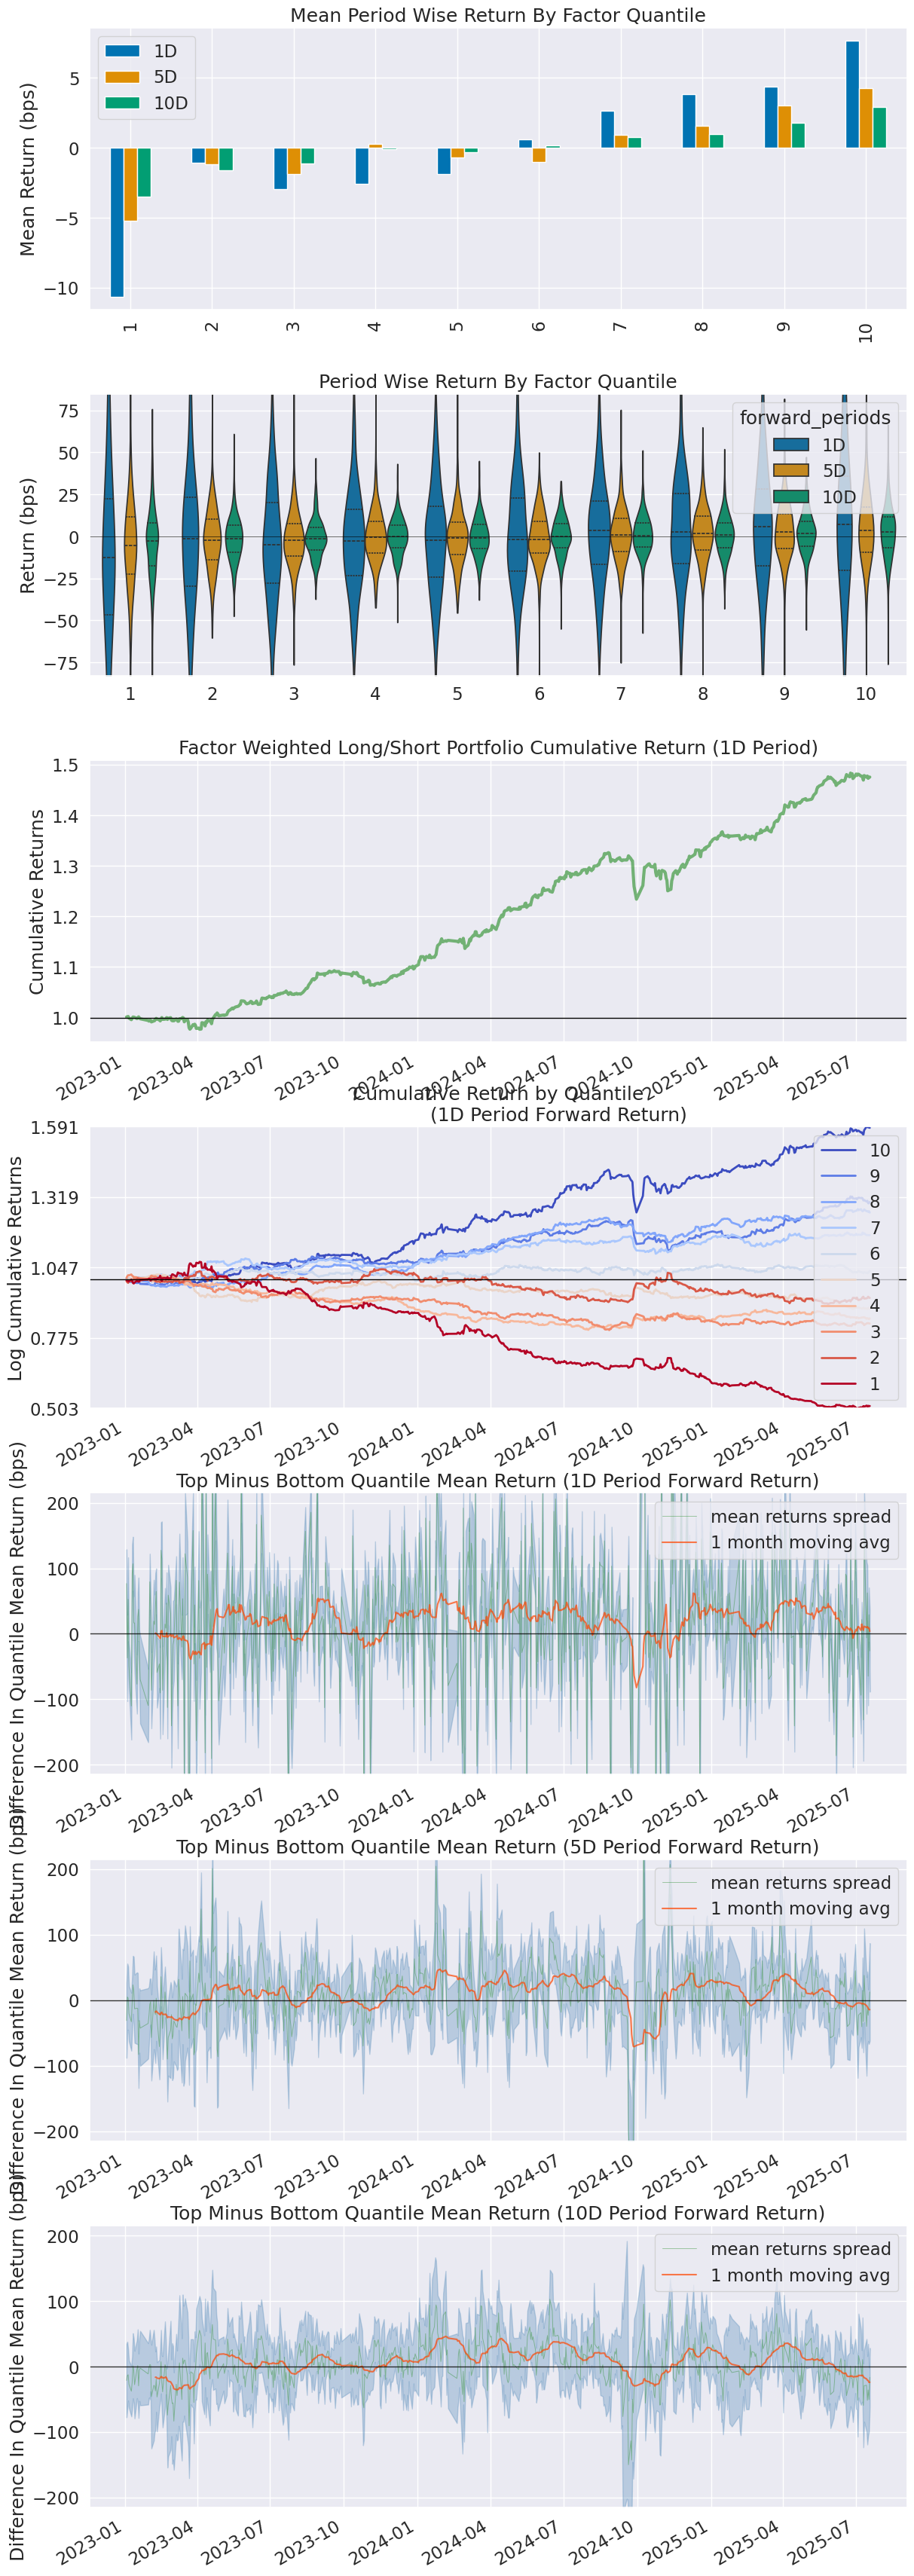

Information Analysis


,1D,5D,10D
IC Mean,0.046,0.053,0.046
IC Std.,0.139,0.133,0.135
Risk-Adjusted IC,0.331,0.397,0.337
t-stat(IC),8.217,9.841,8.351
p-value(IC),0.000,0.000,0.000
IC Skew,-0.086,0.198,0.241
IC Kurtosis,0.552,0.582,0.187


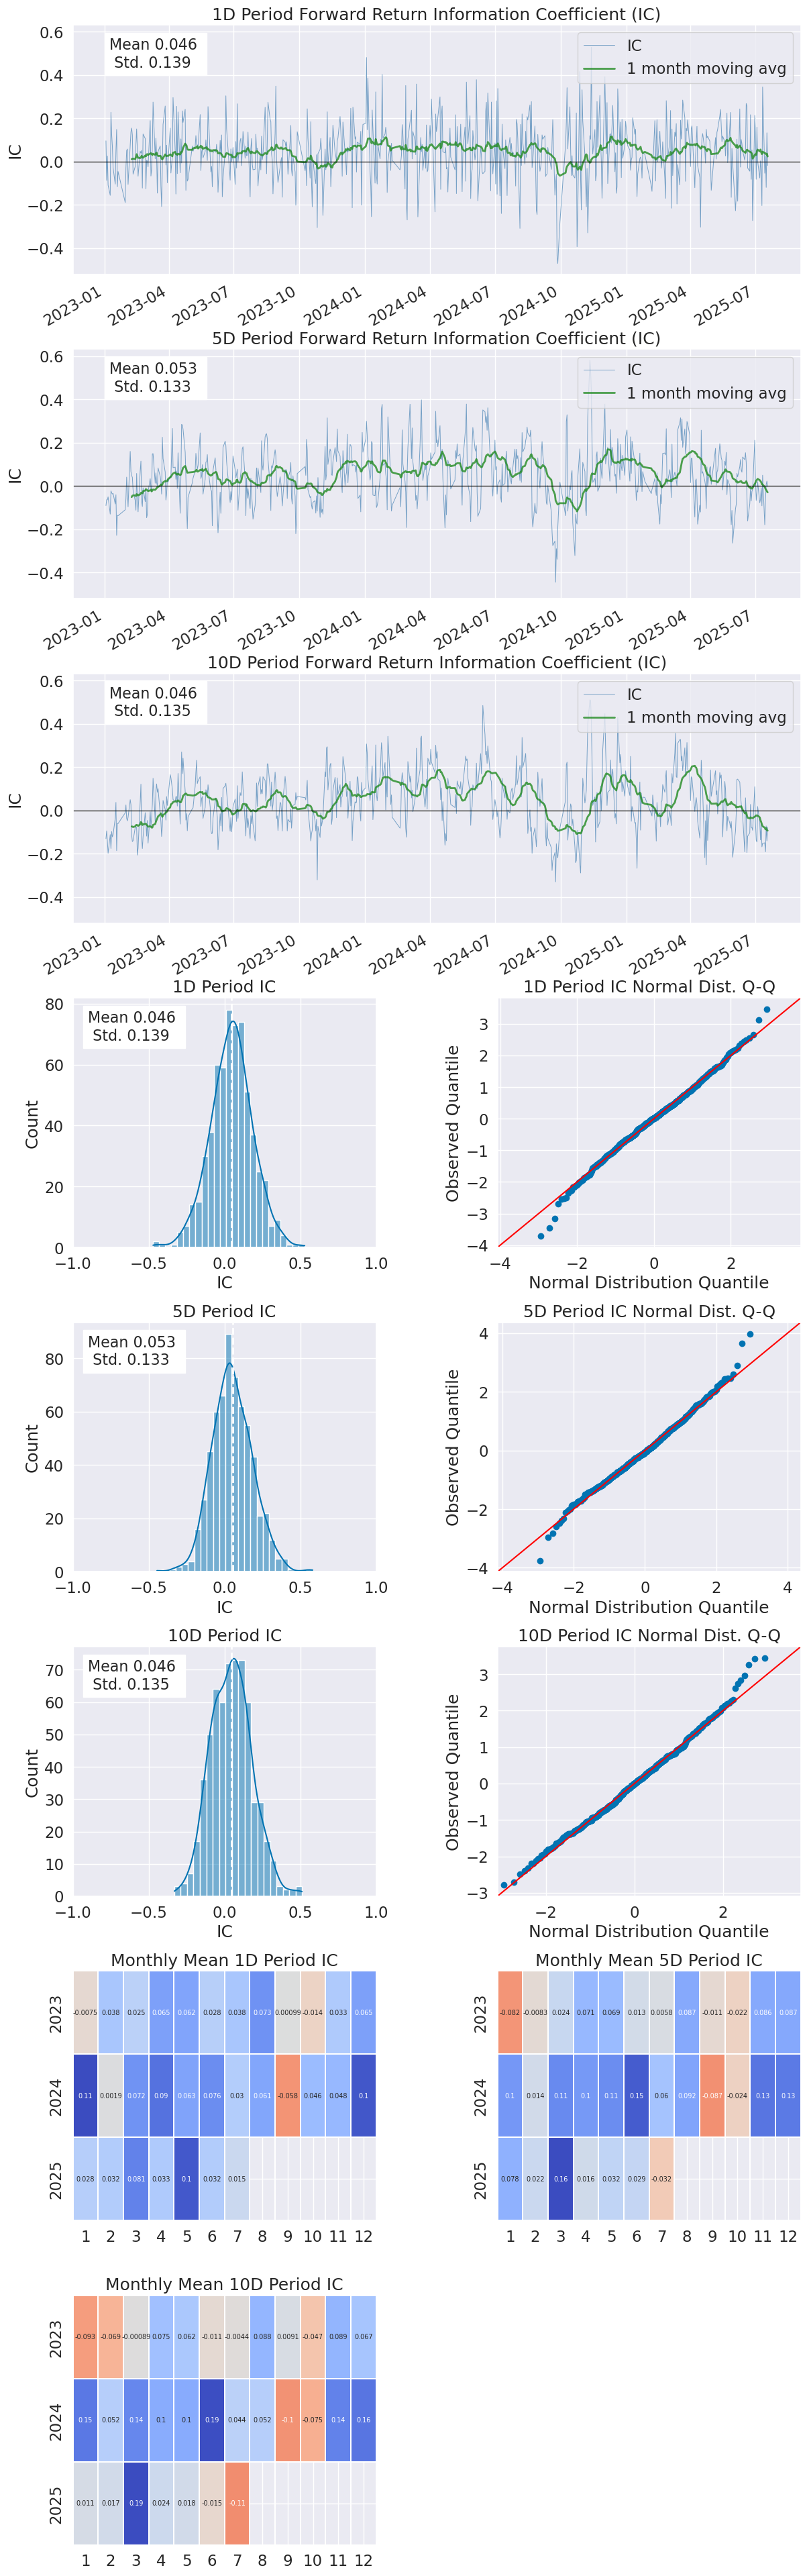

/home/hyd/miniforge3/envs/python311/lib/python3.11/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.567,0.801,0.814
Quantile 2 Mean Turnover,0.791,0.869,0.886
Quantile 3 Mean Turnover,0.833,0.884,0.890
Quantile 4 Mean Turnover,0.853,0.891,0.898
Quantile 5 Mean Turnover,0.867,0.892,0.899
Quantile 6 Mean Turnover,0.862,0.890,0.897
Quantile 7 Mean Turnover,0.859,0.896,0.891
Quantile 8 Mean Turnover,0.842,0.884,0.890
Quantile 9 Mean Turnover,0.797,0.873,0.878
Quantile 10 Mean Turnover,0.594,0.802,0.837


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.598,0.232,0.164


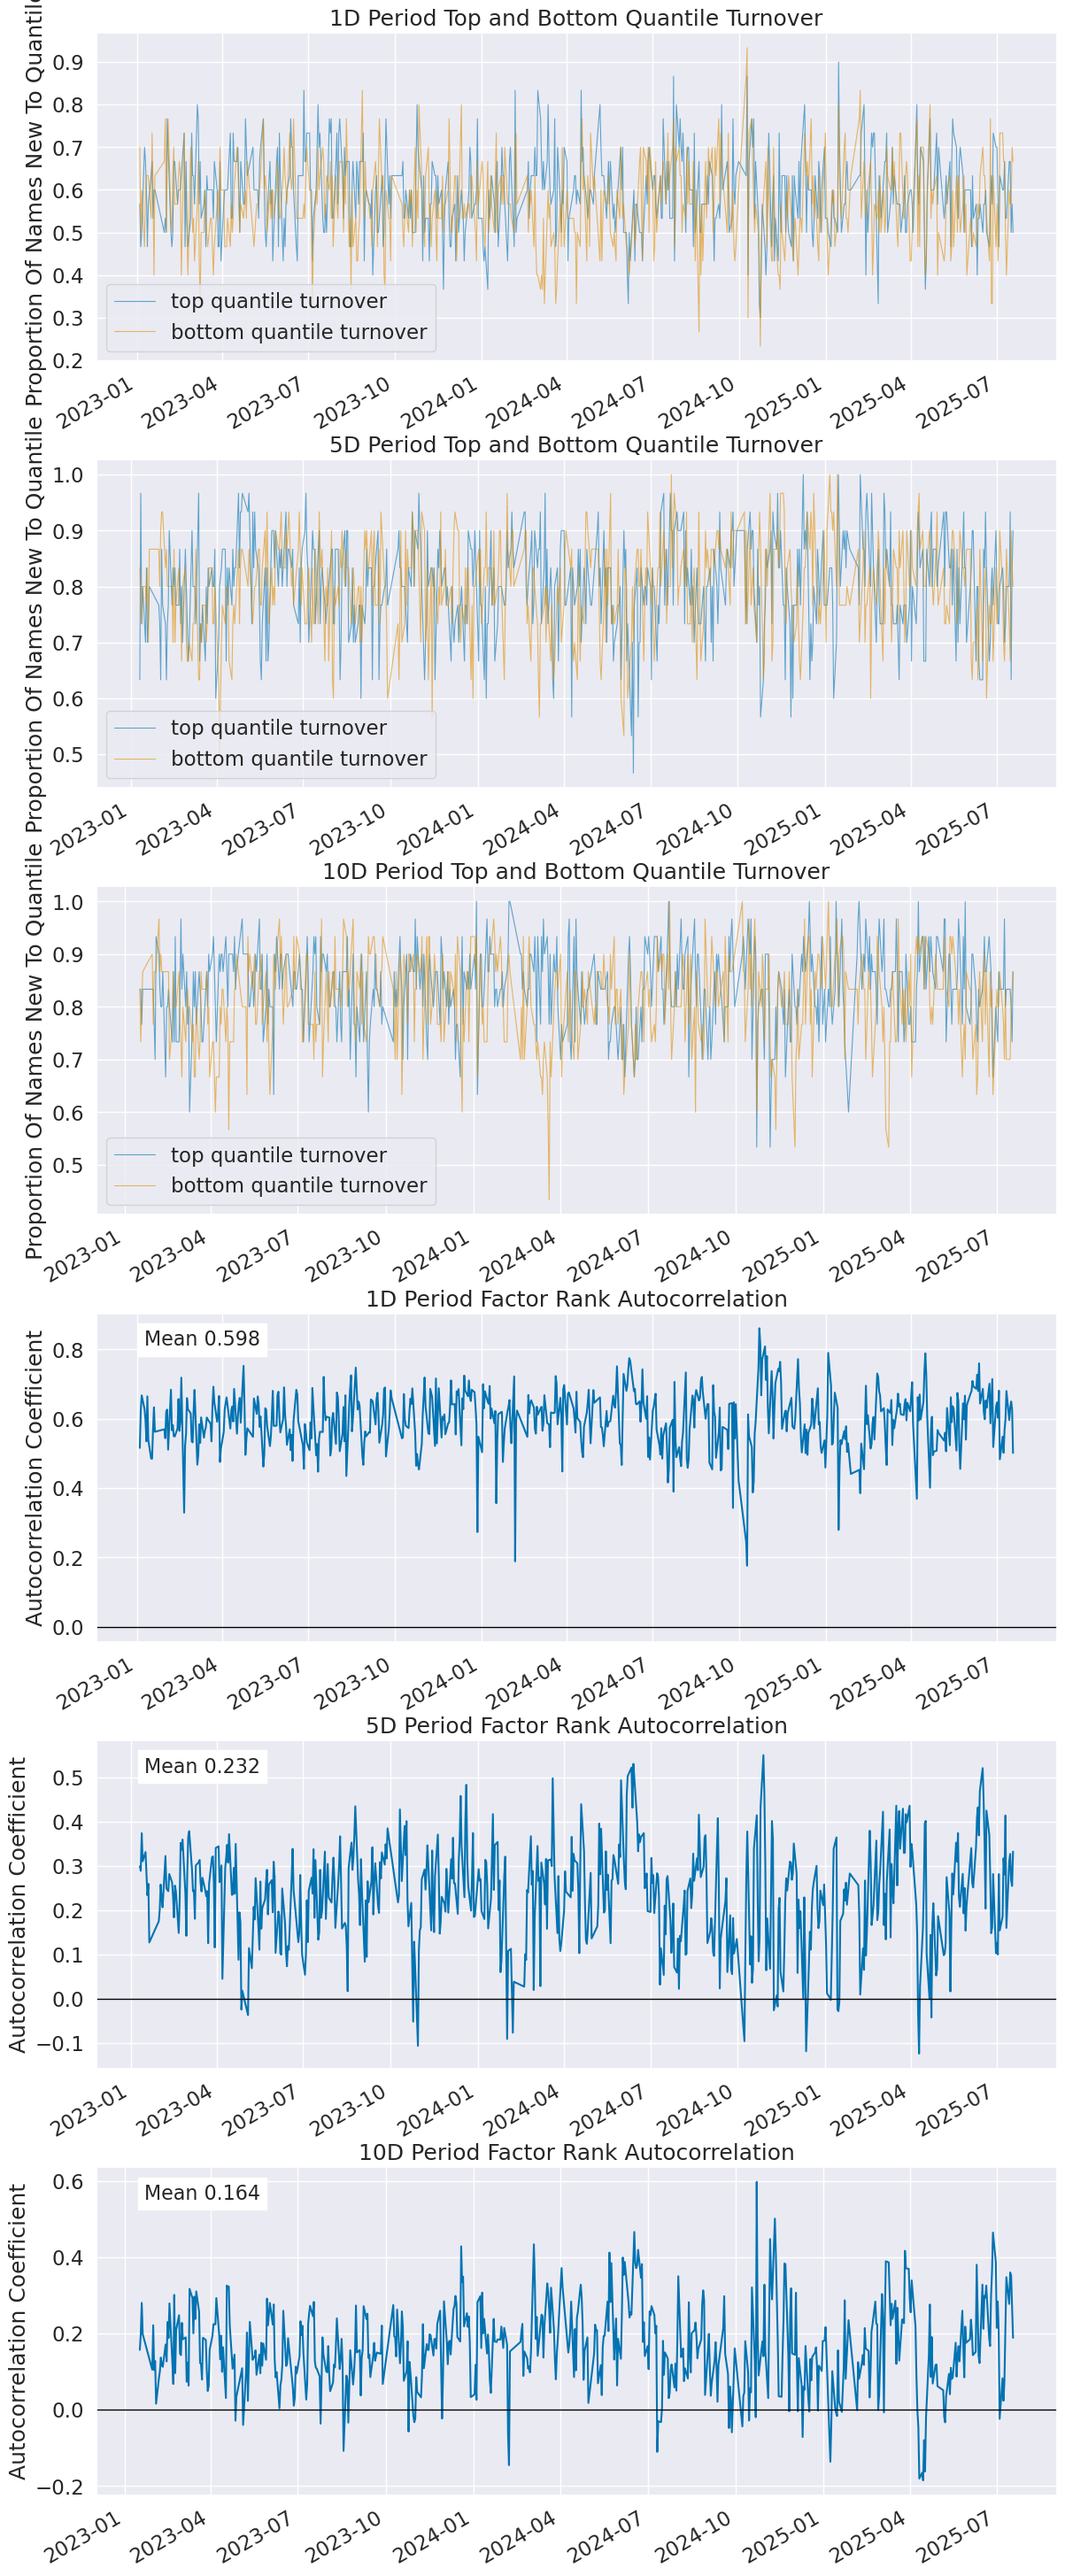

In [27]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [28]:
# 保存信号数据
lab.save_signal(name, signal, interval=_interval_str if "_interval_str" in globals() else "1d")

# 策略回测

In [29]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [30]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [31]:
# 从文件加载信号数据
signal = lab.load_signal(name, interval=_interval_str if "_interval_str" in globals() else "1d")

In [32]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数（对齐 TEST 时间段）
from vnpy.alpha.dataset import to_datetime
test_start_dt = to_datetime(test_period[0])
test_end_dt = to_datetime(test_period[1])

# 使用实际产生过信号的标的集合，避免引入无信号标的
vt_pool = signal["vt_symbol"].unique().to_list()

engine.set_parameters(
    vt_symbols=vt_pool,
    interval=Interval.DAILY,
    start=test_start_dt,
    end=test_end_dt,
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [33]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2025-10-23 13:44:17 开始加载历史数据


100%|██████████| 357/357 [00:02<00:00, 138.39it/s]

2025-10-23 13:44:20 所有历史数据加载完成
2025-10-23 13:44:20 策略初始化完成
2025-10-23 13:44:20 开始回放历史数据


2025-10-23 13:44:22 历史数据回放结束
2025-10-23 13:44:22 开始计算逐日盯市盈亏
2025-10-23 13:44:22 逐日盯市盈亏计算完成
2025-10-23 13:44:22 开始计算策略统计指标
2025-10-23 13:44:22 ------------------------------
2025-10-23 13:44:22 首个交易日：  2023-01-03
2025-10-23 13:44:22 最后交易日：  2025-08-01
2025-10-23 13:44:22 总交易日：  625
2025-10-23 13:44:22 盈利交易日：  299
2025-10-23 13:44:22 亏损交易日：  325
2025-10-23 13:44:22 起始资金：  100,000,000.00
2025-10-23 13:44:22 结束资金：  128,277,983.54
2025-10-23 13:44:22 总收益率：  28.28%
2025-10-23 13:44:22 年化收益：  10.86%
2025-10-23 13:44:22 最大回撤:   -20,905,582.07
2025-10-23 13:44:22 百分比最大回撤: -19.89%
2025-10-23 13:44:22 最长回撤天数:   381
2025-10-23 13:44:22 总盈亏：  28,277,983.54
2025-10-23 13:44:22 总手续费：  8,637,159.89
2025-10-23 13:44:22 总成交金额：  11,546,649,949.42
2025-10-23 13:44:22 总成交笔数：  3419
2025-10-23 13:44:22 日均盈亏：  45,244.77
2025-10-23 13:44:22 日均手续费：  13,819.46
2025-10-23 13:44:22 日均成交金额：  18,474,639.92
2025-10-23 13:44:22 日均成交笔数：  5.4704
2025-10-23 13:44:22 日均收益率：  0.05%
2025-10-23 13:44:22 收益标准差：  1.04%
2025-10

In [35]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)